# Turning locomotion controller — Flybody

This tutorial runs the v2 hybrid turning controller on the flybody model on flat terrain. A two-value descending signal modulates the left/right CPG amplitudes and directions, and the hybrid correction rules produce low-level joint angle and adhesion commands.

The only Flybody-specific subtlety here is the **CPG output ordering**. `HybridController` builds its joint-angle output by name lookup using plain `BodySegment`/`RotationAxis`/`JointDOF` types from `flygym.anatomy`. Flybody's `get_actuated_jointdofs_order` returns `FlybodyJointDOF` instances built from `FlybodyBodySegment`/`FlybodyRotationAxis`. Because frozen dataclasses and enums only compare equal within the same concrete class, we must convert the dof order to plain types before handing it to the controller (the index order is preserved, so the resulting joint-angle array still maps 1-for-1 onto the Flybody position actuators).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange

from flygym import Simulation
from flygym.anatomy import BodySegment, JointDOF, RotationAxis
from flygym.compose import ActuatorType, FlatGroundWorld, KinematicPosePreset
from flygym.compose.fly import FlybodyFly
from flygym.flybody import (
    FlybodyActuatedDOFPreset,
    FlybodyAxisOrder,
    FlybodyContactBodiesPreset,
    FlybodyJointPreset,
    FlybodySkeleton,
    FlybodyBodySegment
)
from flygym.utils.math import Rotation3D
from flygym_demo.complex_terrain import (
    HybridControllerObservation,
    HybridTurningController,
    FlybodyPreprogrammedSteps,
    apply_locomotion_action,
)
from flygym_demo.complex_terrain.common import LocomotionAction

output_dir = Path("outputs/flybody_turning_controller")
output_dir.mkdir(parents=True, exist_ok=True)

## Build the Flybody fly

Legs-only joints, position-controlled active leg DoFs, and leg adhesion — same active DOF layout (42 position actuators, 6 adhesion outputs) as the standard locomotion fly, but using the Flybody skeleton, axis convention, and neutral pose.

In [2]:
axis_order = FlybodyAxisOrder.YAW_ROLL_PITCH
neutral_pose = KinematicPosePreset.FLYBODY_NEUTRAL

fly = FlybodyFly(name="flybody")
skeleton = FlybodySkeleton(
    axis_order=axis_order,
    joint_preset=FlybodyJointPreset.LEGS_ONLY,
)
fly.add_joints(skeleton, neutral_pose)

actuated_dofs = fly.skeleton.get_actuated_dofs_from_preset(
    FlybodyActuatedDOFPreset.LEGS_ACTIVE_ONLY
)
fly.add_actuators(actuated_dofs, ActuatorType.POSITION)
fly.add_leg_adhesion()
fly.colorize()

body_cam = fly.add_tracking_camera(
    name="body_cam",
    pos_offset=(0.0, -8.0, 1.0),
    rotation=Rotation3D("euler", (1.57, 0.0, 0.0)),
    fovy=35.0,
)

world = FlatGroundWorld()
world.add_fly(
    fly,
    [0, 0, 0.7],
    Rotation3D("quat", [1, 0, 0, 0]),
    bodysegs_with_ground_contact=FlybodyContactBodiesPreset.TIBIA_TARSUS_ONLY,
    add_ground_contact_sensors=False,
)

sim = Simulation(world)
renderer = sim.set_renderer(
    [body_cam],
    camera_res=(240, 320),
    playback_speed=0.1,
    output_fps=25,
)

Applying wing default pose correction.


## Build the controller — converting the DOF order

`fly.get_actuated_jointdofs_order(POSITION)` returns Flybody-typed `FlybodyJointDOF` objects. The hybrid controller builds an internal `dict[JointDOF, angle]` using plain `JointDOF(BodySegment, BodySegment, RotationAxis)` keys, so we rebuild the order with the plain types. Because we only rebuild the element types (not the order), the resulting joint-angle array still lines up with the Flybody position actuators index-by-index.

In [3]:
def to_plain_dof_order(flybody_dof_order):
    """Cast a list of FlybodyJointDOF into plain JointDOF, preserving order."""
    return [
        JointDOF(
            BodySegment(d.parent.name),
            BodySegment(d.child.name),
            RotationAxis(d.axis.value),
        )
        for d in flybody_dof_order
    ]

flybody_dof_order = fly.get_actuated_jointdofs_order(ActuatorType.POSITION)
controller_dof_order = to_plain_dof_order(flybody_dof_order)

preprogrammed_steps = FlybodyPreprogrammedSteps()
controller = HybridTurningController(
    timestep=sim.timestep,
    preprogrammed_steps=preprogrammed_steps,
    output_dof_order=controller_dof_order,
    enable_adhesion=False, # disable adhesion as somehow it leads to the fly rearing ???
)

print("Position actuators:", len(flybody_dof_order))
print("Simulation timestep:", sim.timestep)

Position actuators: 42
Simulation timestep: 0.0001


## Apply the initial pose

In [4]:
sim.reset()
controller.reset(seed=0)

initial_action = LocomotionAction(
    joint_angles=preprogrammed_steps.default_pose_by_dof_order(controller_dof_order),
    adhesion_onoff=np.ones(6, dtype=bool),
)

apply_locomotion_action(sim, fly.name, initial_action)
sim.warmup()

## Run the turning controller

Descending command turns one way for the first half of the run, then the other way.

In [5]:
run_time = 2.0
nsteps_sim = int(run_time / sim.timestep)
time_grid = np.arange(nsteps_sim) * sim.timestep

thorax_idx = fly.get_bodysegs_order().index(FlybodyBodySegment("c_thorax"))
thorax_positions = np.full((nsteps_sim, 3), np.nan, dtype=np.float32)
cpg_magnitudes = np.full((nsteps_sim, 6), np.nan, dtype=np.float32)
descending_signals = np.full((nsteps_sim, 2), np.nan, dtype=np.float32)

for step_idx in trange(nsteps_sim, desc="Running flybody turning controller"):
    curr_time = step_idx * sim.timestep
    if curr_time < run_time / 2:
        descending_signal = np.array([0.4, 1.2])
    else:
        descending_signal = np.array([1.2, 0.4])
        
    obs = HybridControllerObservation.from_sim(sim, fly.name)
    action = controller.step(descending_signal, obs)
    apply_locomotion_action(sim, fly.name, action)
    sim.step_with_profile()

    thorax_positions[step_idx] = sim.get_body_positions(fly.name)[thorax_idx]
    cpg_magnitudes[step_idx] = controller.cpg_network.curr_magnitudes
    descending_signals[step_idx] = descending_signal

    sim.render_as_needed_with_profile()

print("Rendered frames:", len(renderer.frames[body_cam.full_identifier]))
print(
    "Final thorax displacement:",
    np.round(thorax_positions[-1] - thorax_positions[0], 3),
    "mm",
)
sim.print_performance_report()

Running flybody turning controller: 100%|██████████| 20000/20000 [00:15<00:00, 1276.32it/s]

Rendered frames: 500
Final thorax displacement: [ 1.844 13.29  -0.374] mm
PERFORMANCE PROFILE


Stage,Time/step (us),Percent (%),Throughput (iters/s),Throughput x realtime
Physics simulation advancement,128,42,7794,0.78
Rendering*,179,58,5573,0.56
TOTAL,308,100,3250,0.32


* Note: 500 frames were rendered out of 20000 steps. Therefore, rendering time per image is 7177 us.


In [6]:
sim.renderer.show_in_notebook()
sim.renderer.save_video(output_dir / "flybody_turning_controller.mp4")

flybody/body_cam This browser does not support the video tag.


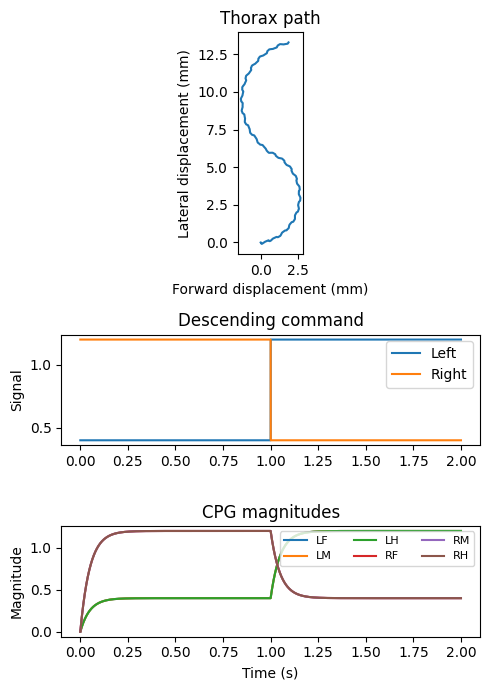

In [7]:
fig, axes = plt.subplots(
    3, 1, figsize=(5, 7), tight_layout=True, height_ratios=[2, 1, 1]
)

axes[0].plot(
    thorax_positions[:, 0] - thorax_positions[0, 0],
    thorax_positions[:, 1] - thorax_positions[0, 1],
)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("Forward displacement (mm)")
axes[0].set_ylabel("Lateral displacement (mm)")
axes[0].set_title("Thorax path")

axes[1].plot(time_grid, descending_signals[:, 0], label="Left")
axes[1].plot(time_grid, descending_signals[:, 1], label="Right")
axes[1].set_ylabel("Signal")
axes[1].set_title("Descending command")
axes[1].legend()

for leg_idx, leg in enumerate(preprogrammed_steps.legs):
    axes[2].plot(time_grid, cpg_magnitudes[:, leg_idx], label=leg.upper())
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Magnitude")
axes[2].set_title("CPG magnitudes")
axes[2].legend(ncols=3, fontsize=8)

fig.savefig(output_dir / "flybody_turning_controller_diagnostics.png")